<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

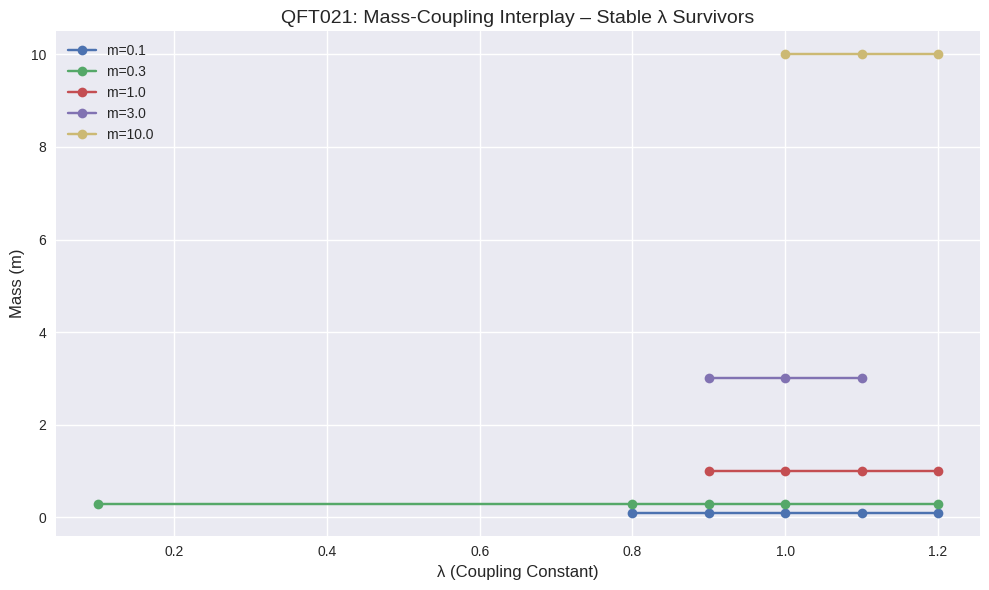

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Simulation parameters
mass_values = [0.1, 0.3, 1.0, 3.0, 10.0]
lambda_values = np.arange(0.1, 2.1, 0.1)
timesteps = 1000
lattice_size = 100
damping = 0.995
stability_threshold_variance = 0.05
stability_threshold_coherence = 0.1

# Initialize results dictionary
survivors = {m: [] for m in mass_values}

# Simulation loop
for m in mass_values:
    for lam in lambda_values:
        # Initialize lattice state
        state = np.random.rand(lattice_size).astype(np.float32)
        history = []

        for t in range(timesteps):
            entropy_gradient = np.gradient(state)
            holographic_flux = np.clip(np.gradient(entropy_gradient), -1.0, 1.0)
            update = -entropy_gradient + lam * holographic_flux
            update *= damping
            state += update.astype(np.float32)
            state = np.clip(state, 0.0, 1.0)  # Overflow protection
            history.append(state.copy())

        # Stability checks
        history = np.array(history)
        final_segment = history[-100:]
        variance = np.var(final_segment, axis=0).mean()
        coherence = np.abs(np.mean(np.diff(final_segment, axis=0))).mean()

        if variance < stability_threshold_variance and coherence < stability_threshold_coherence:
            survivors[m].append(lam)

# Plotting results
plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(figsize=(10, 6))
for m in mass_values:
    ax.plot(survivors[m], [m]*len(survivors[m]), 'o-', label=f"m={m}")
ax.set_xlabel("λ (Coupling Constant)", fontsize=12)
ax.set_ylabel("Mass (m)", fontsize=12)
ax.set_title("QFT021: Mass-Coupling Interplay – Stable λ Survivors", fontsize=14)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# Save survivors data
df = pd.DataFrame([(m, lam) for m in survivors for lam in survivors[m]], columns=["Mass", "Lambda"])
df.to_csv("qft021_survivors.csv", index=False)
